# Milestone 1

## Researching Star Wars Action Figures: A Data Mining Opportunity

The Star Wars franchise is a global phenomenon, generating billions of dollars in revenue across various industries, including collectibles. One of the most popular product lines within this universe is Star Wars action figures. Collectors and casual fans alike fuel a highly dynamic market, with prices fluctuating based on factors such as rarity, character significance, and media appearances. This presents a valuable opportunity for data mining to develop predictive models that estimate the future value of action figures. For businesses like online retailers, auction platforms, or collectible shops, gaining insights into which figures will appreciate in value can optimize inventory management, pricing strategies, and auction reserves.

The target audience for this data mining project is twofold: first, businesses involved in selling or trading Star Wars memorabilia, and second, collectors who want data-driven insights into their purchasing decisions. Retailers can use predictive models to determine which figures to stock or promote based on market trends, while collectors can make informed choices on which items are worth purchasing or holding onto for future gains.

## Project Plan

The project will begin by gathering data on Star Wars characters and their associated action figures. The primary data sources will include the Star Wars Databank (starwars.com/databank), which provides comprehensive information about characters, movies, and series, and Action Figures 411 (actionfigures411.com), a website containing pricing information, action figure release dates, and conditions. The data collected will include variables such as:

* Character name and attributes (e.g., species, affiliations, appearances in films or series)
* Action figure details (e.g., condition, release date, rarity, price history)
* Popularity trends based on recent media exposure (e.g., appearances in movies or series)

A key component of the project will be data integration. The collected data from the Star Wars Databank will be joined with pricing and condition information from Action Figures 411 to create a rich dataset. To extend the analysis, additional data sources may be explored, including scraping auction sites like eBay for price trends or using movie/TV show release schedules to analyze the impact of new media on character popularity.

The project will also explore how to collect real-time data on media releases (e.g., from news websites or social media trends) to predict when action figures might surge in popularity. By incorporating these external factors, the model can be fine-tuned to predict price spikes in advance of major Star Wars film or series releases, allowing businesses and collectors to maximize value.

## Technology Used in the Project

The project will use Python, Pandas, and machine learning libraries such as Scikit-learn for model building and data analysis, with Jupyter Notebook as the development environment.

## Concerns for the Project

While this project presents an exciting opportunity to explore the Star Wars action figure market, several concerns need to be addressed. First, the availability of comprehensive and reliable data may be limited. Although sites like Star Wars Databank and Action Figures 411 offer a solid foundation, they may not contain all the necessary details on pricing history, condition, or real-time popularity trends. Additionally, not all data may be openly accessible, and scraping auction or retail sites like eBay could present legal or technical challenges.

Another concern is the complexity of integrating multiple data sources to generate accurate predictions. Predicting future price trends based on media appearances, new series releases, and collector demand introduces a level of uncertainty that may exceed the scope of this course. Combining historical data with real-time trend analysis, and accounting for unpredictable market shifts, can lead to model overfitting or inaccurate predictions if not handled carefully. As a result, while the project will strive to develop robust predictive models, the complexity of accurately forecasting market behavior might be constrained by both the available data and the limits of the course material.

## Initial Exploratory Data Analysis

This is an initial exploratory data analysis.  I have brought in two files and will be using these files to graph some initial data about the Star Wars Franchise information.  This includes things like number of characters in the star wars universe, characters by gender, count of series or film the character appears in, etc.  This is not a complete dataset.  Throughout the term, I will be adding in additional information to the dataset and will be attempting to identify additional data points which will help to predict action figure pricing.

### Import required packages

In [17]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, median_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

sample_size = 5
random_state = 42
data_path = "../data"

### Read in initial dataset

In [5]:
clean_data = pd.read_csv(f"{data_path}/character_appearances_data.csv", encoding='ISO-8859-1')

### Plot Number of Characters per Film

This chart shows the number of characters in each Star Wars Film.  This information will help us to understand which films should have the highest number of action figures.  As we look at the waxing and waning popularity of the films during action figure analysis, we should see that some films have a high number of action figures (based on character count) but may need to dig deeper to understand each character's popularity within the film or franchise to determine why that character's price may be changing over time.

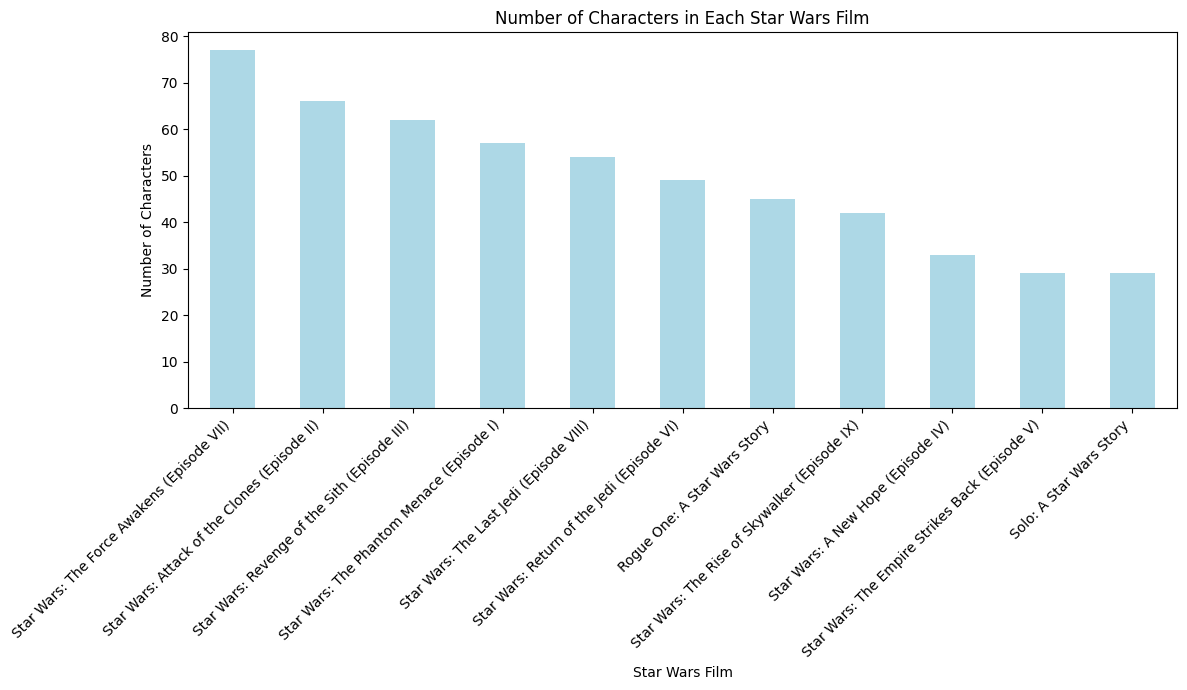

In [6]:
# Filter the dataset to focus on 'films' media type instead
film_data = clean_data[clean_data['media type'] == 'films']

# Group the data by appearance name (which corresponds to the Star Wars film) and count the characters in each
film_character_counts = film_data['appearance name'].value_counts()

# Plot the graph
plt.figure(figsize=(12, 7))
film_character_counts.plot(kind='bar', color='lightblue')
plt.title('Number of Characters in Each Star Wars Film')
plt.xlabel('Star Wars Film')
plt.ylabel('Number of Characters')
plt.xticks(rotation=45, ha='right', fontsize=10)  # Adjust rotation and alignment
plt.tight_layout()
plt.show()


### Data Clean up prior to graphing

When graphing the count of appearances by media type, I noticed that some data was not populated correctly from source.  I manually looked this up online and am correcting the data here.

In [7]:
# Filter the dataset for records where the media type is "Appearances"
appearances_records = clean_data[clean_data['media type'] == 'Appearances']

# Display the first few records
appearances_records.head()

,id,name,gender,species,dimension type,dimension size,character databank link,media type,media key,appearance name
125,616b2b6ca415f492a01ad05b,BB-8,unknown,unknown,Height,0.67m,https://www.starwars.com/databank/bb-8,Appearances,star-wars-forces-of-destiny,Star Wars: Forces of Destiny
733,616b2e09fc9aa492a01ad05b,Jyn Erso,female,human,NaN,unknown,https://www.starwars.com/databank/jyn-erso,Appearances,star-wars-forces-of-destiny,Star Wars: Forces of Destiny
1193,616b2b6181af8492a01ad05b,Rey,female,human,Height,1.7m,https://www.starwars.com/databank/rey,Appearances,star-wars-forces-of-destiny,Star Wars: Forces of Destiny


In [8]:
# manually looked up online and determined that the Star Wars: Forces of Destiny is an animated series.
# updating to correct value
clean_data.loc[clean_data['media type'] == 'Appearances', 'media type'] = 'series'

### Plot Number of Titles by Media Type

Here we explore the number of titles per media type.  We can see that there are many titles in the games/apps media type.  Series and films take on the bulk of the remainder of titles and interactive apps (such as VR) appear to be less common.  This is important because we may be able to see a change in action figure pricing based on a character's appearance in a given title or media type.  For example, it may be interesting to see if one character's action figure prices increase because they are more commonly appearing in video games compared to other characters that more commonly appear in film or television series.

#### Note: Age Brackets

One piece of data I may not be able to obtain, but would be interesting is to see the age brackets at which some action figures should be most commonly purchased.  For example, it would be interesting to know if characters that appear solely or primarily in animated television series are more often purchased by parents for young children.  While intuitively this would seem to make sense, it would be interesting to see if this is actually supported in the data.

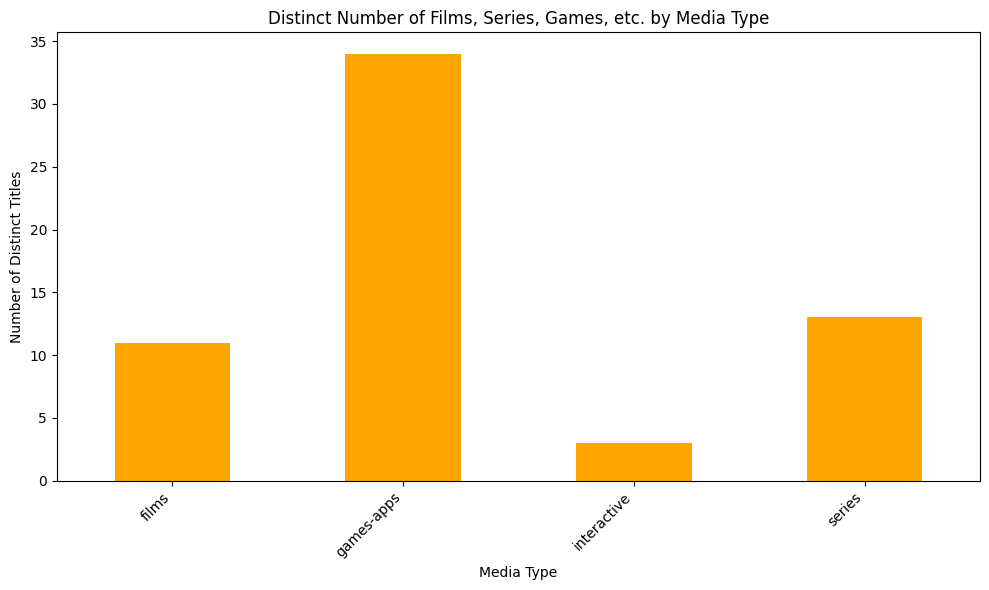

In [9]:
# Group the data by media type and count distinct values for 'appearance name' (which corresponds to films, series, games, etc.)
distinct_media_counts = clean_data.groupby('media type')['appearance name'].nunique()

# Plot the graph
plt.figure(figsize=(10, 6))
distinct_media_counts.plot(kind='bar', color='orange')
plt.title('Distinct Number of Films, Series, Games, etc. by Media Type')
plt.xlabel('Media Type')
plt.ylabel('Number of Distinct Titles')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

### Plotting Gender and Species

Here, I am looking at the intersection of gender and species.  We can see that in the human species, the number of male characters far exceeds the number of female characters.  We also see that in the Twi-Lek species, females are more common than males.  While evaluating action figure pricing, we may check to see if the gender with lower counts for a given species impact the action figure prices for that character.  For example, would a Princess Leia figure be more valuable because she is one of a smaller number of female human characters in the universe.  It is logical that because female characters are fewer that there would be more demand for these characters. 

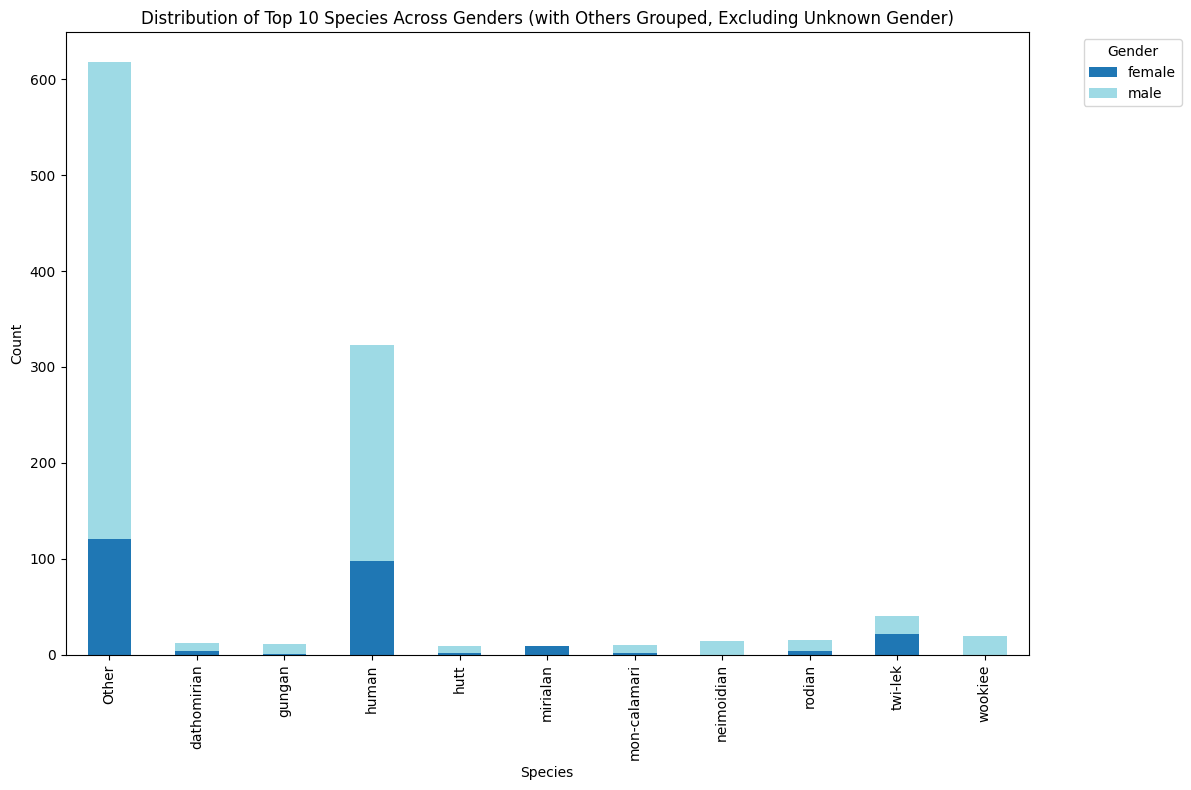

In [10]:
# Filter out 'unknown' species and calculate the counts of remaining species
species_counts = clean_data[clean_data['species'] != 'unknown']['species'].value_counts()

# Identify the top 10 species by count
top_10_species = species_counts.head(10)

# Group all other species as "Other"
clean_data['species_grouped'] = clean_data['species'].apply(lambda x: x if x in top_10_species.index else 'Other')

# Filter out rows where the gender is 'unknown'
filtered_data_no_unknown_gender = clean_data[clean_data['gender'] != 'unknown']

# Recreate the stacked bar chart with the top 10 species and "Other", excluding 'unknown' gender
species_gender_counts_top_10_no_unknown = pd.crosstab(filtered_data_no_unknown_gender['species_grouped'], filtered_data_no_unknown_gender['gender'])

# Plot the stacked bar chart
species_gender_counts_top_10_no_unknown.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='tab20')
plt.title('Distribution of Top 10 Species Across Genders (with Others Grouped, Excluding Unknown Gender)')
plt.xlabel('Species')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Plot the number of times a character appears in different titles

Here I am looking to see how many titles a character appears in.  The intent is to determine the characters that may be more popular because they are central to the lore of the Star Wars universe.  I am intentionally pulling the top 10 characters that appeared in the most number of titles.  It is likely that there will be many action figures for these characters released at different times since the Franchise inception.  It may be interesting to see if action figures were made for specific titles that these characters appeared in, would that impact prices of the figure.  For example, is a Darth Vader action figure from a video game (e.g., Fallen Order) more valuable than an action figure of Darth Vader from the film Star Wars: Revenge of the Sith (Episode III).

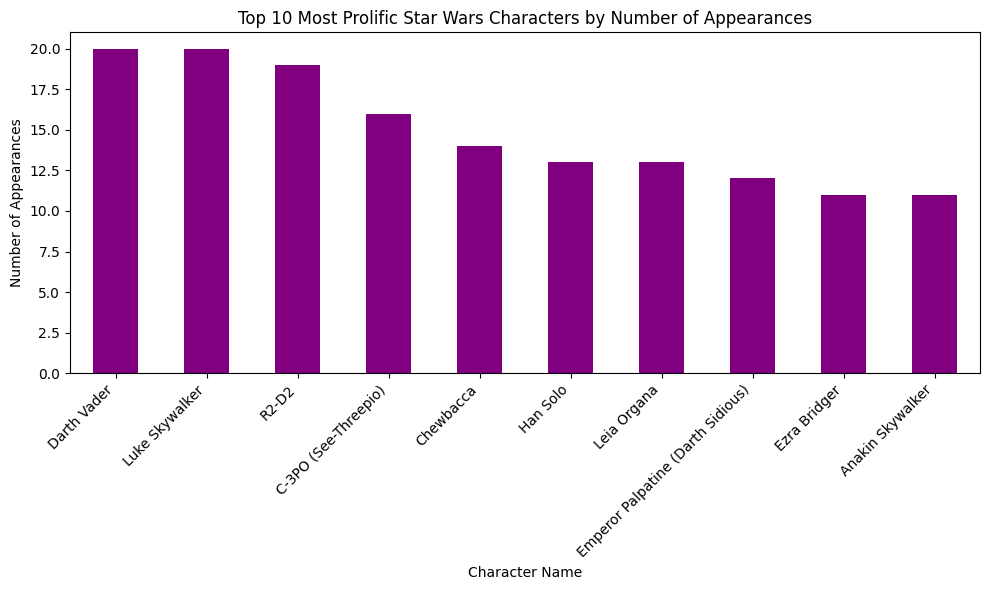

In [11]:
# Group the data by character name and count the number of appearances for each character
character_appearance_counts = clean_data['name'].value_counts().head(10)

# Plot a bar chart for the most prolific characters by appearance count
plt.figure(figsize=(10, 6))
character_appearance_counts.plot(kind='bar', color='purple')
plt.title('Top 10 Most Prolific Star Wars Characters by Number of Appearances')
plt.xlabel('Character Name')
plt.ylabel('Number of Appearances')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Summary - Milestone 1

In this first milestone, I am presenting the business case for analyzing Star Wars Action Figure Prices.  I also explore some information regarding the characters in the Star Wars Universe to begin initial Exploratory Data Analysis on which characters we might want to focus our analysis on.  We also explore the general business model of the Star Wars Franchise by investigating the types of media and it's appeal to gender based marketing.  In the next milestone, I intend to bring in additional data points including some action figure pricing to begin identifying features which may help be indicators for predicting price.

# Milestone 2

In this portion of the project I will begin preparing the data for modeling.  The transformations below are on a performed on a list of action figures available for characters in the Star Wars franchise.  This data was collected by combining data from Star Wars databank, actionfigures411.com and galacticfigures.com.  While not included in this weeks submission, I plan to include the python files used to collect this information in my github repository.  

## Load and explore the data

In [12]:
# Load the data
df = pd.read_csv(f"{data_path}/06_star_wars_character_combined_unique.csv")

In [13]:
df.describe()

,accessory_count,joint_count,msrp,released,scale_inches,year_imprinted
count,4489.000000,4491.000000,2442.000000,4491.000000,4492.000000,2994.000000
mean,2.466696,10.519706,29.749574,2011.409931,4.188390,2022.415164
std,1.959669,5.646155,43.479344,9.302517,0.924913,546.792323
min,0.000000,0.000000,0.000000,1978.000000,3.750000,1977.000000
25%,1.000000,5.000000,9.990000,2006.000000,3.750000,2002.000000
50%,2.000000,10.000000,19.990000,2012.000000,3.750000,2007.000000
75%,3.000000,14.000000,29.990000,2019.000000,3.750000,2010.000000
max,21.000000,39.000000,499.990000,2025.000000,11.000000,22008.000000


In [14]:
df.columns

Index(['uuid_character', 'character_name', 'appearance',
       'figure_collection_name', 'accessory_count', 'exclusive', 'joint_count',
       'msrp', 'released', 'scale_inches', 'variations recorded',
       'year_imprinted', 'currency', 'appearance_type', 'appearance_name',
       'appearance_year', 'appearance_link', 'character_detail_link'],
      dtype='object')

In [15]:
df.shape

(4492, 18)

In [18]:
df.sample(sample_size, random_state=random_state)

,uuid_character,character_name,appearance,figure_collection_name,accessory_count,exclusive,joint_count,msrp,released,scale_inches,variations recorded,year_imprinted,currency,appearance_type,appearance_name,appearance_year,appearance_link,character_detail_link
157,aa3633d59a367018862548aa71ce6f6d,Mars Guo,The Phantom Menace,Tatooine Podrace,4.0,No,7.0,6.99,2006.0,3.75,No,2006.0,USD,MOVIES,The Phantom Menace,(1999),https://galacticfigures.com/star-wars-figures....,https://galacticfigures.com/figureDetails.aspx...
2525,c7f2fb4099dd99f772aa17b0db90141c,Captain Phasma,The Force Awakens,The Force Awakens Titanium Series,9.0,No,6.0,14.99,2017.0,3.75,No,NaN,USD,MOVIES,The Force Awakens,(2015),https://galacticfigures.com/star-wars-figures....,https://galacticfigures.com/figureDetails.aspx...
1020,82af77b8f4a1447fb734b32dffe5f14f,Darth Vader,A New Hope,Star Wars,3.0,No,18.0,19.99,2017.0,6.00,No,NaN,USD,MOVIES,A New Hope,(1977),https://galacticfigures.com/star-wars-figures....,https://galacticfigures.com/figureDetails.aspx...
1119,eed12347537ab817da5866cd239c37e1,Han Solo,A New Hope,A New Hope,1.0,Disney Store,14.0,12.95,2018.0,5.00,No,NaN,USD,MOVIES,A New Hope,(1977),https://galacticfigures.com/star-wars-figures....,https://galacticfigures.com/figureDetails.aspx...
731,4c2a466c9a3c4b3cffdbb3c17dfac012,Commander Cody,Revenge Of The Sith,Revenge Of The Sith,2.0,No,5.0,NaN,2014.0,3.75,No,2013.0,NaN,MOVIES,Revenge Of The Sith,(2005),https://galacticfigures.com/star-wars-figures....,https://galacticfigures.com/figureDetails.aspx...


## Filling Missing Values

* Identify columns with missing values
* Fill missing categorical columns
* Fill missing numerical columns

In [19]:
# observe missing values
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
print("Missing values in each column:")
print(missing_counts)

Missing values in each column:
figure_collection_name     311
accessory_count              3
exclusive                   41
joint_count                  1
msrp                      2050
released                     1
year_imprinted            1498
currency                  2066
dtype: int64


### Fill missing categorical values

* *Rationale:*

    * `figure_collection_name`: Filled missing values with `"Unknown"`. This decision was made because missing values indicate a lack of data about the figure’s collection, not an intrinsic attribute of the figure itself. "Unknown" serves as a placeholder, allowing the model to still recognize and utilize these records without falsely assuming specific attributes.
    * `exclusive`: Filled missing values with `"No"`. A missing value in this context is likely to mean the figure isn't exclusive rather than just missing the information. Using `"No"` helps avoid skewing the model.
    * `currency`: Filled missing values with the mode (`"USD"`). Since `"USD"` was the predominant currency, using it for imputation prevents introducing a significant deviation in the dataset's consistency. This is important to ensure that data-driven predictions aren’t affected by irrelevant variability.

In [20]:
# Fill missing values in categorical columns

# For collection name, filling with unknown since this was not able to be determined
df['figure_collection_name'] = df['figure_collection_name'].fillna('Unknown')

# For exclusive, filling with "No"
df['exclusive'] = df['exclusive'].fillna('No')

# For currency, filling with mode which should be USD
df['currency'] = df['currency'].fillna(df['currency'].mode()[0])

### Fill missing numerical values

* *Rationale:*
  * `accessory_count` and `joint_count`: Filled with the `median`. These features are numerical and potentially contain outliers. `Median` imputation is appropriate since it is less sensitive to outliers, thus preserving the central tendency without being skewed by extreme values.
  * 1released1: The single missing value for a figure from "Solo" was manually filled with 2018. This approach was taken because the release year could be visually verified, and using the median seemed unnecessary due to the specificity of the missing value.
  * `year_imprinted`: Filled missing values using `released` year. This imputation is appropriate because, in many cases, the year a figure was imprinted aligns closely with the year it was released. This choice reduces potential inconsistencies and aligns similar records.
  * `msrp`: Filled with the `median` value for now, with the plan to refine these values in ***Milestone 3 by scraping more accurate pricing data***. This ensures that the model has values for training but also highlights areas for improvement.

In [21]:
# Fill missing values in numerical columns with the median
df['accessory_count'] = df['accessory_count'].fillna(df['accessory_count'].median())
df['joint_count'] = df['joint_count'].fillna(df['joint_count'].median())

# Only one value for figure in the film Solo, visually determined to use 2018
# Could also write function to fill with median of figures from Solo but seemed overkill
df['released'] = df['released'].fillna(2018)

# when the year_imprinted is missing fill it with the released year
df['year_imprinted'] = df['year_imprinted'].fillna(df['released'])

# For MSRP, I'm going to fill with the median for now.  However, for Milestone 3, I'm going
# to attempt to pull additional pricing trends from actionfigures411.com and use those values
# for figures currently missing MSRP.  I may still not be able to get them all, but may plug
# some gaps.
df['msrp'] = df['msrp'].fillna(df['msrp'].median())

## Feature Engineering

* Evaluate Unique domain values from columns
* Drop unnecessary columns
* Split Appearance Year into Start and End Years
* Create dummy variables for columns with less than 100 distinct values
* Encode Character Name and Figure Collection Name

In [22]:
# check for unique counts in categorical columns
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"Column '{col}' has {df[col].nunique()} distinct values.")

Column 'uuid_character' has 4068 distinct values.
Column 'character_name' has 859 distinct values.
Column 'appearance' has 23 distinct values.
Column 'figure_collection_name' has 1340 distinct values.
Column 'exclusive' has 69 distinct values.
Column 'variations recorded' has 29 distinct values.
Column 'currency' has 1 distinct values.
Column 'appearance_type' has 2 distinct values.
Column 'appearance_name' has 23 distinct values.
Column 'appearance_year' has 23 distinct values.
Column 'appearance_link' has 24 distinct values.
Column 'character_detail_link' has 4068 distinct values.


### Dropping Columns

* **Rationale:**
    * The columns `uuid_character`, `appearance_link`, and `character_detail_link` were dropped because they represent unique identifiers or URLs, which are not directly useful for predicting action figure prices. They are metadata used for reference or identification rather than meaningful features for the predictive model.

In [23]:
# drop uuid and link columns
# these fields are being dropped because they are references on
# where the data was collected and unique id for each figure,
# but they should not be predictive.
df = df.drop(columns=['uuid_character','appearance_link','character_detail_link'])
df.sample(sample_size, random_state=random_state)

,character_name,appearance,figure_collection_name,accessory_count,exclusive,joint_count,msrp,released,scale_inches,variations recorded,year_imprinted,currency,appearance_type,appearance_name,appearance_year
157,Mars Guo,The Phantom Menace,Tatooine Podrace,4.0,No,7.0,6.99,2006.0,3.75,No,2006.0,USD,MOVIES,The Phantom Menace,(1999)
2525,Captain Phasma,The Force Awakens,The Force Awakens Titanium Series,9.0,No,6.0,14.99,2017.0,3.75,No,2017.0,USD,MOVIES,The Force Awakens,(2015)
1020,Darth Vader,A New Hope,Star Wars,3.0,No,18.0,19.99,2017.0,6.00,No,2017.0,USD,MOVIES,A New Hope,(1977)
1119,Han Solo,A New Hope,A New Hope,1.0,Disney Store,14.0,12.95,2018.0,5.00,No,2018.0,USD,MOVIES,A New Hope,(1977)
731,Commander Cody,Revenge Of The Sith,Revenge Of The Sith,2.0,No,5.0,19.99,2014.0,3.75,No,2013.0,USD,MOVIES,Revenge Of The Sith,(2005)


### Split Appearance Year

* **Rationale:**
  * The `appearance_year` was split to capture different time spans in which a figure might have been relevant (e.g., start and end years for series or movies). This transformation allows the model to more precisely interpret when a character was prominent, which may directly influence its popularity and the corresponding action figure's price. When only one year was available, both `start_appearance_year` and `end_appearance_year` were set to that value, ensuring consistent representation.

In [24]:
# split appearance year into start and end appearance years.
# For movies, this should be a single value (start year)
# For series, this may be a range (start year and end year of series)
df[['start_appearance_year', 'end_appearance_year']] = df['appearance_year'].apply(
    lambda value: pd.Series(
        re.match(r'\((\d{4})(?:\s-\s(\d{4}|Today))?\)', value).groups() if pd.notna(value) else (None, None)
    ).replace('Today', 2024)
).astype(float)

df['end_appearance_year'] = df['end_appearance_year'].fillna(df['start_appearance_year'])

df = df.drop(columns=['appearance_year'])

# df.sample(5, random_state=142)

### Creating Dummy Variables
* **Rationale:**
  * Dummy variables were created to represent categorical columns with fewer than 100 unique values. This was done to facilitate the use of these features in machine learning models, which often cannot work directly with categorical data. Dummy encoding allows the model to interpret categorical distinctions numerically without introducing false orderings. This approach also helps maintain model interpretability and prevents potential overfitting issues associated with high-cardinality categorical features.  `drop_first=True` was implemented to reduce issues that may arise in some models as a result of multi-collinearity in the data.

In [26]:
# Create dummy variables for categorical fields with less than 100 values
def create_dummies_for_categorical(df):
    for col in df.select_dtypes(include=['object', 'category']).columns:
        if df[col].nunique() < 100:
            df = pd.get_dummies(df, columns=[col], drop_first=True)
            print(f"Created dummy variables for column '{col}'")
    return df

df = create_dummies_for_categorical(df)

df.shape
df.sample(sample_size, random_state=random_state)

,character_name,figure_collection_name,accessory_count,joint_count,msrp,released,scale_inches,year_imprinted,start_appearance_year,end_appearance_year,...,appearance_name_The Acolyte,appearance_name_The Bad Batch,appearance_name_The Book Of Boba Fett,appearance_name_The Clone Wars,appearance_name_The Empire Strikes Back,appearance_name_The Force Awakens,appearance_name_The Last Jedi,appearance_name_The Mandalorian,appearance_name_The Phantom Menace,appearance_name_The Rise Of Skywalker
157,Mars Guo,Tatooine Podrace,4.0,7.0,6.99,2006.0,3.75,2006.0,1999.0,1999.0,...,False,False,False,False,False,False,False,False,True,False
2525,Captain Phasma,The Force Awakens Titanium Series,9.0,6.0,14.99,2017.0,3.75,2017.0,2015.0,2015.0,...,False,False,False,False,False,True,False,False,False,False
1020,Darth Vader,Star Wars,3.0,18.0,19.99,2017.0,6.00,2017.0,1977.0,1977.0,...,False,False,False,False,False,False,False,False,False,False
1119,Han Solo,A New Hope,1.0,14.0,12.95,2018.0,5.00,2018.0,1977.0,1977.0,...,False,False,False,False,False,False,False,False,False,False
731,Commander Cody,Revenge Of The Sith,2.0,5.0,19.99,2014.0,3.75,2013.0,2005.0,2005.0,...,False,False,False,False,False,False,False,False,False,False


### Encoding columns with many distinct values

* **Rationale:**
  * Label encoding was applied to the `character_name` and `figure_collection_name` high-cardinality columns to assign a unique numerical value to each category. This is different from dummy encoding, as it’s more efficient for high-cardinality data. Each unique `character_name` and `figure_collection_name` was assigned an integer, which allows models that can handle categorical-like numerical values (e.g., tree-based models) to process these fields. This approach avoids the curse of dimensionality that would result from one-hot encoding, given the large number of distinct values.

This encoding may not strictly be necessary during the modeling portion of Milestone 3 depending on the models chosen.  However, I wanted to be proactive at performing this encoding.

In [27]:
# Converting character names and figure collection names to numerical values
columns_to_encode = ['character_name','figure_collection_name']
for col in columns_to_encode:
    df[col] = df[col].astype('category').cat.codes
    print(f"Encoded column '{col}' as numerical values")

Encoded column 'character_name' as numerical values
Encoded column 'figure_collection_name' as numerical values


## Review the state of the data after preparing for modeling

* Display a sample of the data
* Verify that all columns have numeric values which can be used in most models
* Verify that columns are not missing values
* Check there are no categorical fields with distinct domain values

In [28]:
df.sample(sample_size, random_state=random_state)

,character_name,figure_collection_name,accessory_count,joint_count,msrp,released,scale_inches,year_imprinted,start_appearance_year,end_appearance_year,...,appearance_name_The Acolyte,appearance_name_The Bad Batch,appearance_name_The Book Of Boba Fett,appearance_name_The Clone Wars,appearance_name_The Empire Strikes Back,appearance_name_The Force Awakens,appearance_name_The Last Jedi,appearance_name_The Mandalorian,appearance_name_The Phantom Menace,appearance_name_The Rise Of Skywalker
157,470,960,4.0,7.0,6.99,2006.0,3.75,2006.0,1999.0,1999.0,...,False,False,False,False,False,False,False,False,True,False
2525,126,982,9.0,6.0,14.99,2017.0,3.75,2017.0,2015.0,2015.0,...,False,False,False,False,False,True,False,False,False,False
1020,220,924,3.0,18.0,19.99,2017.0,6.00,2017.0,1977.0,1977.0,...,False,False,False,False,False,False,False,False,False,False
1119,332,125,1.0,14.0,12.95,2018.0,5.00,2018.0,1977.0,1977.0,...,False,False,False,False,False,False,False,False,False,False
731,196,839,2.0,5.0,19.99,2014.0,3.75,2013.0,2005.0,2005.0,...,False,False,False,False,False,False,False,False,False,False


In [29]:
# check transformed data for modeling readiness
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4492 entries, 0 to 4491
Columns: 151 entries, character_name to appearance_name_The Rise Of Skywalker
dtypes: bool(141), float64(8), int16(2)
memory usage: 917.0 KB


In [30]:
# observe missing values
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
print("Missing values in each column:")
print(missing_counts)

Missing values in each column:
Series([], dtype: int64)


In [31]:
# check for unique counts in categorical columns
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"Column '{col}' has {df[col].nunique()} distinct values.")

In [32]:
df.to_csv(f"{data_path}/07_star_wars_character_modeling.csv", index=False)

## Summary - Milestone 2

The transformations applied in this milestone collectively aimed to ensure the dataset is complete, consistent, and structured in a manner suitable for building predictive models. I have attempted to strike a balance between maintaining as much of the original data as possible and ensuring that the transformations add value to the modeling process.

### Next Steps / Concerns

After reviewing the available data, the transformations have removed many of the interesting categorical data points that I would like to have retained.  It is likely that I will add an intermediate data frame that will allow me to tie back my outputs of modeling to the original categorical data for visualizing the results.  

More importantly, I noticed that there is a significant number of missing values for MSRP.  I also do not feel like I have sufficient pricing data for sales over time.  Therefore, I am going to attempt to pull some additional data from actionfigure411.com over the next couple of weeks and combine it here.  In some cases, I may be able to get both current, average, and high price based on their sales information.  In other cases, I may be able to obtain historical price data for each sale of the figure from the site.  However, pulling this data does require a large amount of web scraping and I worry that I will not be able to complete the work for a sufficient population of characters.

Oh, and I need to go back to Milestone 1 and refactor the data and visualizations.  I found the data I was able to collect from galactic figures much more manageable than that from the StarWars.com databank.  I believe I can replicate many graphs from the milestone using this data, but in places I cannot I may attempt to join the data together into a superset or replace the milestone 1 charts with versions that work on this data.

# Milestone 3 - Model Building and Evaluation

In Milestone 3, you will begin the process of selecting, building, and evaluating a model. You are required to train and evaluate at least one model in this milestone. Write step-by-step for performing each of these steps. You can use any methods/tools you think are most appropriate, but you should explain/justify why you are selecting the model(s) and evaluation metric(s) you choose. It is important to think about what type of model and metric makes sense for your problem. Again, do what makes the most sense for your project. Write a short overview/conclusion of the insights gained from your model building/evaluation.

It is important to note that these milestones are meant to keep you on track for the final project submission. At any point, you can pivot or modify your project as needed based on what you discover. These milestones are not final versions; they are drafts of the many steps you need to complete along the way.
As a reminder, Teams is a great place to discuss your project with your peers. Feel free to solicit feedback/input (without creating a group project!) and collaborate on your projects with your peers.

Each milestone will build on top of each other, so make sure you do not fall behind. Submit Milestones 1-3 together. I recommend building your project milestones in a Jupyter Notebook, building upon one another. However, make sure it is clear where each milestone begins and ends.

## Reusable Functions for Modeling

* `evaluate_model` takes in the necesary values to calculate model metrics for all regression models
* `plot_feature_importances` takes in the necessary information to plot the feature importance of each model (except linear regression which was intentionally excluded)

In [33]:
# Function to evaluate model performance
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (len(y_true) - 1) / (len(y_true) - X_test.shape[1] - 1)
    medae = median_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Adjusted R2': adj_r2,
        'MEDAE': medae,
        'MAPE': mape
    }

# Feature Importances Plotting Function
def plot_feature_importances(model, model_name, feature_names, top_n=10):
    plt.figure(figsize=(10, 6))
    feature_importances = model.named_steps['regressor'].feature_importances_ if hasattr(model.named_steps['regressor'], 'feature_importances_') else model.named_steps['regressor'].get_feature_importance()
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
    importance_df = importance_df.sort_values(by='Importance', ascending=False).head(top_n)
    sns.barplot(x='Importance', y='Feature', data=importance_df)
    plt.title(f'Top {top_n} Feature Importances for {model_name}')
    plt.show()

## Read in the Data File

* Read the data file from csv
* Display a sample of the file data
* Plot distribution of MSRP

In [34]:
# Load the dataset
file_path = f"{data_path}/07_star_wars_character_modeling.csv"
data = pd.read_csv(file_path)

# Display the first few rows to understand the data structure
data.sample(sample_size, random_state=random_state)

,character_name,figure_collection_name,accessory_count,joint_count,msrp,released,scale_inches,year_imprinted,start_appearance_year,end_appearance_year,...,appearance_name_The Acolyte,appearance_name_The Bad Batch,appearance_name_The Book Of Boba Fett,appearance_name_The Clone Wars,appearance_name_The Empire Strikes Back,appearance_name_The Force Awakens,appearance_name_The Last Jedi,appearance_name_The Mandalorian,appearance_name_The Phantom Menace,appearance_name_The Rise Of Skywalker
157,470,960,4.0,7.0,6.99,2006.0,3.75,2006.0,1999.0,1999.0,...,False,False,False,False,False,False,False,False,True,False
2525,126,982,9.0,6.0,14.99,2017.0,3.75,2017.0,2015.0,2015.0,...,False,False,False,False,False,True,False,False,False,False
1020,220,924,3.0,18.0,19.99,2017.0,6.00,2017.0,1977.0,1977.0,...,False,False,False,False,False,False,False,False,False,False
1119,332,125,1.0,14.0,12.95,2018.0,5.00,2018.0,1977.0,1977.0,...,False,False,False,False,False,False,False,False,False,False
731,196,839,2.0,5.0,19.99,2014.0,3.75,2013.0,2005.0,2005.0,...,False,False,False,False,False,False,False,False,False,False


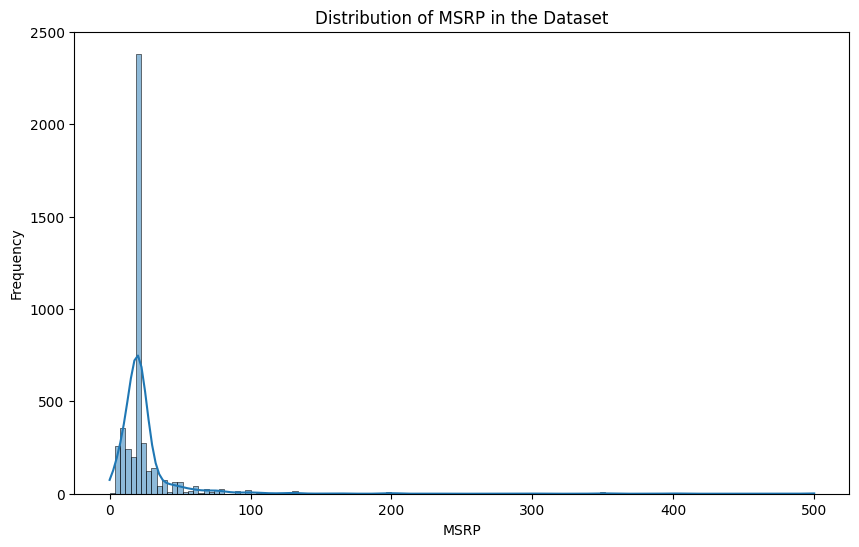

In [35]:
# Plotting the distribution of MSRP in the dataset before handling outliers
plt.figure(figsize=(10, 6))
sns.histplot(data['msrp'], kde=True)
plt.title('Distribution of MSRP in the Dataset')
plt.xlabel('MSRP')
plt.ylabel('Frequency')
plt.show()

## Prepare the Data For Modeling

* Create X (features) by dropping msrp (target) and character_name
* Create y (target) by handling outliers and setting msrp as target
* Convert Boolean columns to integers in X (features)
* Convert Numeric Features to int64 or float64
* Convert categorical features to objects
* Split data into train/test sets
* Plot the MSRP Distribution after handling outliers

In [36]:
# Define features and target
X = data.drop(columns=['msrp', 'character_name'])  # Dropping character_name as it is non-numeric and won't be used directly
# Cap MSRP outliers based on quantiles
upper_limit = data['msrp'].quantile(0.90)
data['msrp'] = np.where(data['msrp'] > upper_limit, upper_limit, data['msrp'])
y = data['msrp']

# Convert boolean columns to integers
bool_features = X.select_dtypes(include=['bool']).columns
X[bool_features] = X[bool_features].astype(int)

# Preprocessing for numeric and categorical features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

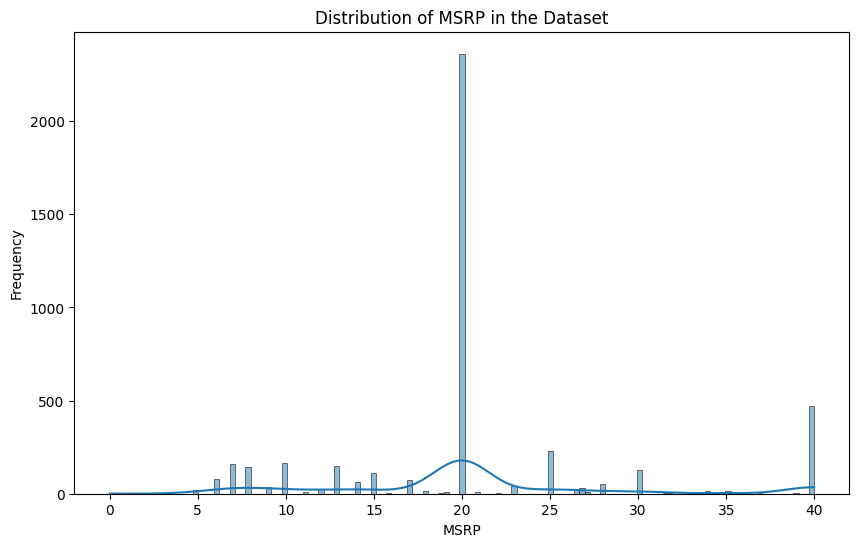

In [37]:
# Plotting the distribution of MSRP in the dataset after handling outliers
plt.figure(figsize=(10, 6))
sns.histplot(data['msrp'], kde=True)
plt.title('Distribution of MSRP in the Dataset')
plt.xlabel('MSRP')
plt.ylabel('Frequency')
plt.show()

## Prepare Pipelines

Note:  These steps are not strictly necessary due to work performed in Milestone 2.  However, after learning about pipelines, I decided I would add them in just to learn the syntax.  They are not providing much value since the data is already fully encoded to numeric and boolean values.  The most value we get here is pulling the feature names after fitting the preprocessor.

* Define transformer for numeric features
* Define transformer for categorical features
* Combine transformers using ColumnTransformer
* Fit the preprocessor (ColumnTransformer) to the Training Data
* Transform the Training Data using the preprocessor
* Extract features after preprocessor is fitted

In [38]:
# Define transformers for numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Fit the preprocessor separately to extract feature names
preprocessor.fit(X_train)

# Transform the training data to extract the feature names after fitting
X_train_transformed = preprocessor.transform(X_train)

# Extract feature names after the preprocessor is fitted
numeric_feature_names = numeric_features.tolist()
categorical_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
categorical_encoder.fit(X[categorical_features])  # Fit the OneHotEncoder explicitly
categorical_feature_names = categorical_encoder.get_feature_names_out(categorical_features)
feature_names = numeric_feature_names + list(categorical_feature_names)

## Create the Pipelines for all models to be evaluated

* Pipeline for Linear Regression Model (baseline)
* Pipeline for Gradient Boosting Model
* Pipeline for CatBoost Model
* Pipeline for LightGBM Model
* Pipeline for XGBoost Model

In [39]:
# Create pipelines for Linear Regression, Gradient Boosting, CatBoost, LightGBM, and XGBoost models
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

catboost_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', CatBoostRegressor(n_estimators=100, random_state=42, verbose=0))
])

lgbm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(n_estimators=100, random_state=42, verbose=0))
])

xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators=100, random_state=42, verbosity=0))
])

## Perform Cross-Validation to Evaluate Models

All models will be evaluated using 5 folds with neg_mean_absolute_error as the scoring methodology.  Results will be stored and displayed in Grid in Model Evaluation section.

* Evaluate cross-validation on all models
* Create Cross-Validation Results set

In [40]:
# Cross-validation to evaluate all models' robustness
gb_cv_scores = cross_val_score(gb_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
catboost_cv_scores = cross_val_score(catboost_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
linear_cv_scores = cross_val_score(linear_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
lgbm_cv_scores = cross_val_score(lgbm_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

# Cross-validation results visualization
cv_results = {
    'Model': ['Gradient Boosting', 'CatBoost', 'Linear Regression', 'LightGBM', 'XGBoost'],
    'Cross-Validation MAE': [-np.mean(gb_cv_scores), -np.mean(catboost_cv_scores), -np.mean(linear_cv_scores), -np.mean(lgbm_cv_scores), -np.mean(xgb_cv_scores)]
}

c:\codebase\portfolio\Data-Science-Projects\galactic-figures\.gfenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\codebase\portfolio\Data-Science-Projects\galactic-figures\.gfenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\codebase\portfolio\Data-Science-Projects\galactic-figures\.gfenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\codebase\portfolio\Data-Science-Projects\galactic-figures\.gfenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\codebase\portfolio\Data-Science-Projects\galactic-figures

## Train & Predict Baseline LinearRegression Model

In [41]:
# Train Baseline Model
linear_model.fit(X_train, y_train)

# Predict Baseline Model
y_pred_linear = linear_model.predict(X_test)

## Prepare Hyperparameter Tuning

Hyperparameter tuning will be performed using GridSearchCV on all models except LinearRegression.

* Gradient Boosting Hyperparameter tuning
* CatBoost Hyperparameter tuning
* LightGBM Hyperparameter tuning
* XGBoost Hyperparameter tuning

In [42]:
# Hyperparameter tuning using GridSearchCV for all models
param_grid_gb = {
    'regressor__n_estimators': [100, 200, 300, 500],
    'regressor__max_depth': [3, 5, 10],
    'regressor__min_samples_split': [2, 4, 6]
}

# CatBoost Hyperparameter tuning
param_grid_catboost = {
    'regressor__n_estimators': [100, 200, 300, 500],
    'regressor__depth': [3, 5, 10],
    'regressor__learning_rate': [0.01, 0.05, 0.1]
}

# LightGBM Hyperparameter tuning
param_grid_lgbm = {
    'regressor__n_estimators': [100, 200, 300, 500],
    'regressor__num_leaves': [20, 31, 40],
    'regressor__learning_rate': [0.01, 0.05, 0.1]
}

# XGBoost Hyperparameter tuning
param_grid_xgb = {
    'regressor__n_estimators': [100, 200, 300, 500],
    'regressor__max_depth': [3, 5, 10],
    'regressor__learning_rate': [0.01, 0.05, 0.1]
}

## Perform GridSearch For Best Parameters

We will perform a GridSearch to find the best parameters for all Models.

* Gradient Boosting GridSearch
* CatBoost GridSearch
* LightGBM GridSearch
* XGBoost GridSearch

In [43]:
def run_search_and_fit(model, param_grid, X_train, y_train, model_name):
    start_time = time.time()
    grid_search = GridSearchCV(model, param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    search_fit_time = time.time() - start_time

    print(f"Best Parameters from GridSearch for {model_name}: {grid_search.best_params_}")

    return grid_search, search_fit_time

In [44]:
# Gradient Boosting GridSearch
grid_search_gb, search_fit_time_gb = run_search_and_fit(gb_model, param_grid_gb, X_train, y_train, "Gradient Boosting")

Best Parameters from GridSearch for Gradient Boosting: {'regressor__max_depth': 10, 'regressor__min_samples_split': 6, 'regressor__n_estimators': 500}


In [45]:
# CatBoost GridSearch
grid_search_catboost, search_fit_time_catboost = run_search_and_fit(catboost_model, param_grid_catboost, X_train, y_train, "CatBoost")

Best Parameters from GridSearch for CatBoost: {'regressor__depth': 10, 'regressor__learning_rate': 0.1, 'regressor__n_estimators': 500}


In [46]:
# LightGBM GridSearch
grid_search_lgbm, search_fit_time_lgbm = run_search_and_fit(lgbm_model, param_grid_lgbm, X_train, y_train, "LightGBM")

Best Parameters from GridSearch for LightGBM: {'regressor__learning_rate': 0.1, 'regressor__n_estimators': 500, 'regressor__num_leaves': 40}


In [47]:
# XGBoost GridSearch
grid_search_xgb, search_fit_time_xgb = run_search_and_fit(xgb_model, param_grid_xgb, X_train, y_train, "XGBoost")

Best Parameters from GridSearch for XGBoost: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 10, 'regressor__n_estimators': 500}


## Train & Predict the Best Models from GridSearch

* Gradient Boosting
* CatBoost
* LightGBM
* XGBoost

In [48]:
def train_predict_best_models(model, X_train, y_train, model_name):
    start_time = time.time()

    # train model
    current_model = model.best_estimator_
    current_model.fit(X_train, y_train)

    # predict model
    y_pred = current_model.predict(X_test)

    best_model_train_fit_time = time.time() - start_time

    return current_model, y_pred, best_model_train_fit_time

In [49]:
# Train Gradient Boosting
best_gb_model, y_pred_gb, gb_model_train_fit_time = train_predict_best_models(grid_search_gb, X_train, y_train, "Gradient Boost")

In [50]:
# Train CatBoost
best_catboost_model, y_pred_catboost, catboost_model_train_fit_time = train_predict_best_models(grid_search_catboost, X_train, y_train, "CatBoost")

In [51]:
# Train LightGBM
best_lgbm_model, y_pred_lgbm, lgbm_model_train_fit_time = train_predict_best_models(grid_search_lgbm, X_train, y_train, "LightGBM")

c:\codebase\portfolio\Data-Science-Projects\galactic-figures\.gfenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [52]:
# Train XGBoost
best_xgb_model, y_pred_xgb, xgb_model_train_fit_time = train_predict_best_models(grid_search_xgb, X_train, y_train, "XGBoost")

## Create and Fit Ensemble Models

* VotingRegressor
* StackingRegressor

In [53]:
# Create an ensemble model using VotingRegressor
start_time = time.time()
ensemble_model = VotingRegressor(estimators=[('gb', best_gb_model.named_steps['regressor']), 
                                              ('catboost', best_catboost_model.named_steps['regressor']),
                                              ('lgbm', best_lgbm_model.named_steps['regressor']),
                                              ('xgb', best_xgb_model.named_steps['regressor']),
                                              ('linear', linear_model.named_steps['regressor'])])

# Fit the ensemble model
ensemble_model.fit(X_train_transformed, y_train)

# Make predictions with the ensemble model
y_pred_ensemble = ensemble_model.predict(preprocessor.transform(X_test))
voting_model_train_fit_time = time.time() - start_time

c:\codebase\portfolio\Data-Science-Projects\galactic-figures\.gfenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [55]:
# Create a stacking model using StackingRegressor
start_time = time.time()
stacking_model = StackingRegressor(
    estimators=[('gb', best_gb_model.named_steps['regressor']),
                ('catboost', best_catboost_model.named_steps['regressor']),
                ('lgbm', best_lgbm_model.named_steps['regressor']),
                ('xgb', best_xgb_model.named_steps['regressor']),
                ('linear', linear_model.named_steps['regressor'])],
    final_estimator=LinearRegression(),
    n_jobs=-1
)

# Fit the stacking model
stacking_model.fit(X_train_transformed, y_train)

# Make predictions with the stacking model
y_pred_stacking = stacking_model.predict(preprocessor.transform(X_test))
stacking_model_train_fit_time = time.time() - start_time

c:\codebase\portfolio\Data-Science-Projects\galactic-figures\.gfenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [56]:
grid_search_fit_times = {
    "Gradient Boosting": search_fit_time_gb,
    "CatBoost": search_fit_time_catboost,
    "LightGBM": search_fit_time_lgbm,
    "XGBoost": search_fit_time_xgb
}

model_train_fit_times = {
    "Gradient Boosting": xgb_model_train_fit_time,
    "CatBoost": catboost_model_train_fit_time,
    "LightGBM": lgbm_model_train_fit_time,
    "XGBoost": xgb_model_train_fit_time,
    "Ensemble": voting_model_train_fit_time,
    "Stacking": stacking_model_train_fit_time
}

## Display Cross-Validation Results

This section will provide a data grid showing the Cross-Validation Scores for all Models

In [57]:
# Evaluate models and collect results
results = []

results.append(evaluate_model(y_test, y_pred_gb, 'Gradient Boosting'))
results.append(evaluate_model(y_test, y_pred_catboost, 'CatBoost'))
results.append(evaluate_model(y_test, y_pred_linear, 'Linear Regression'))
results.append(evaluate_model(y_test, y_pred_lgbm, 'LightGBM'))
results.append(evaluate_model(y_test, y_pred_xgb, 'XGBoost'))
results.append(evaluate_model(y_test, y_pred_ensemble, 'Ensemble'))
results.append(evaluate_model(y_test, y_pred_stacking, 'Stacking'))

# Convert results to DataFrame and display
results_df = pd.DataFrame(results)

results_df['GridSearch_Time (Seconds)'] = results_df['Model'].map(grid_search_fit_times)
results_df['Model_Train_Predict_Time (Seconds)'] = results_df['Model'].map(model_train_fit_times)

display(results_df)

,Model,MAE,RMSE,R2,Adjusted R2,MEDAE,MAPE,GridSearch_Time (Seconds),Model_Train_Predict_Time (Seconds)
0,Gradient Boosting,1.860561,4.271066,0.774537,0.729685,0.344801,9.463344e+13,70.303825,1.123071
1,CatBoost,2.445745,4.234874,0.778342,0.734247,1.205313,1.087769e+14,48.638386,5.791383
2,Linear Regression,4.970842,6.719685,0.441915,0.330894,3.344715,1.442861e+14,NaN,NaN
3,LightGBM,2.391882,4.376987,0.763216,0.716112,1.072691,1.132041e+14,34.140314,0.570821
4,XGBoost,1.840556,4.053180,0.796954,0.756562,0.336317,9.372360e+13,12.823679,1.123071
5,Ensemble,2.475360,4.206658,0.781286,0.737777,1.224271,1.109248e+14,NaN,17.486826
6,Stacking,2.036218,4.054187,0.796853,0.756441,0.670225,1.030492e+14,NaN,36.460043


## Visualization of Results

* Visualize Cross-Validation Performance
* Visualize Feature Importances for Hyperparameter Tuned Models
* BoxPlot of Outliers

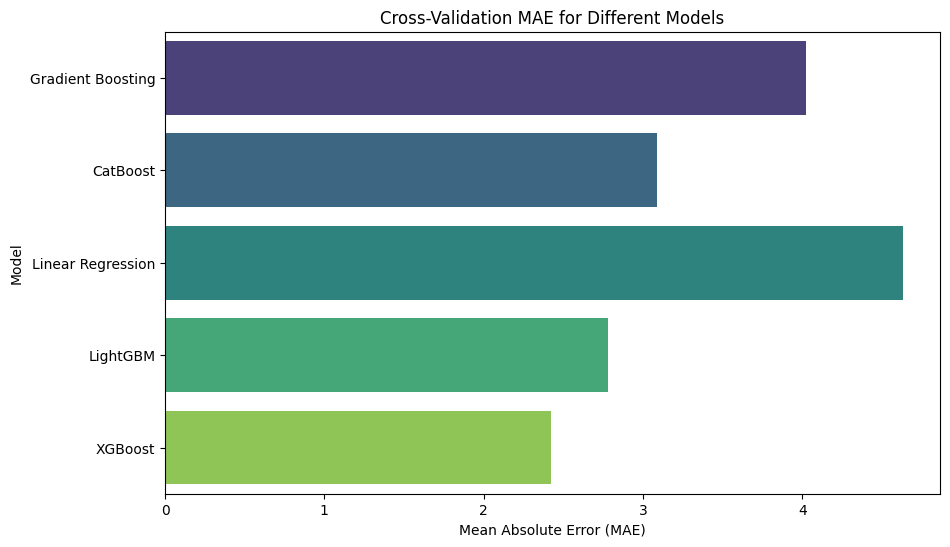

In [58]:
cv_results_df = pd.DataFrame(cv_results)

plt.figure(figsize=(10, 6))
sns.barplot(x='Cross-Validation MAE', y='Model', data=cv_results_df, palette='viridis', hue='Model', dodge=False)
plt.title('Cross-Validation MAE for Different Models')
plt.xlabel('Mean Absolute Error (MAE)')
plt.ylabel('Model')
plt.show()

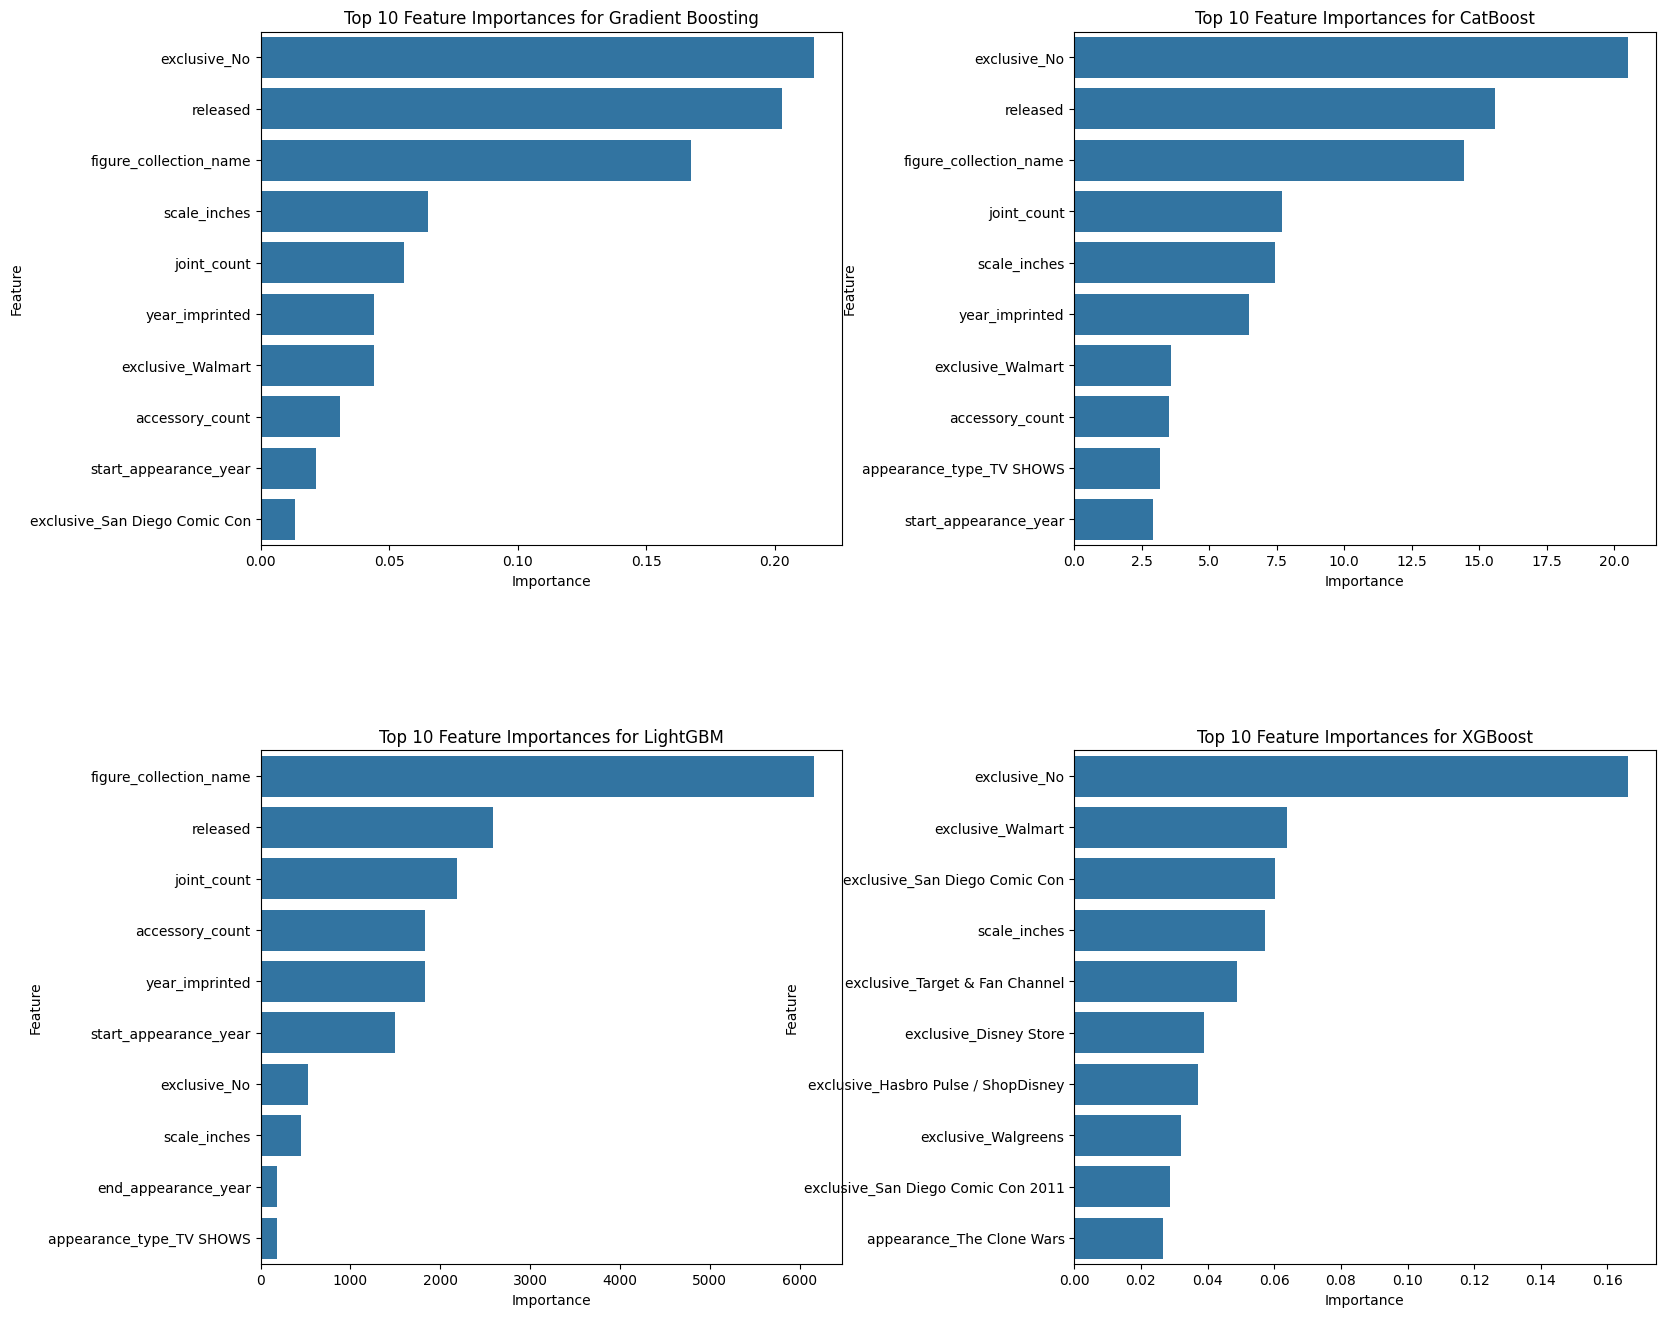

In [59]:
# Create subplots for feature importances
fig, axs = plt.subplots(2, 2, figsize=(18, 16))  # Increased figure size to improve spacing
plt.subplots_adjust(hspace=0.4, wspace=0.4)  # Added wspace to adjust horizontal spacing

models = [
    (best_gb_model, 'Gradient Boosting'),
    (best_catboost_model, 'CatBoost'),
    (best_lgbm_model, 'LightGBM'),
    (best_xgb_model, 'XGBoost')
]

# Plot feature importances for each model
for idx, (model, model_name) in enumerate(models):
    ax = axs[idx // 2, idx % 2]
    feature_importances = model.named_steps['regressor'].feature_importances_ if hasattr(model.named_steps['regressor'], 'feature_importances_') else model.named_steps['regressor'].get_feature_importance()
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
    importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)
    sns.barplot(x='Importance', y='Feature', data=importance_df, ax=ax)
    ax.set_title(f'Top 10 Feature Importances for {model_name}')

plt.show()

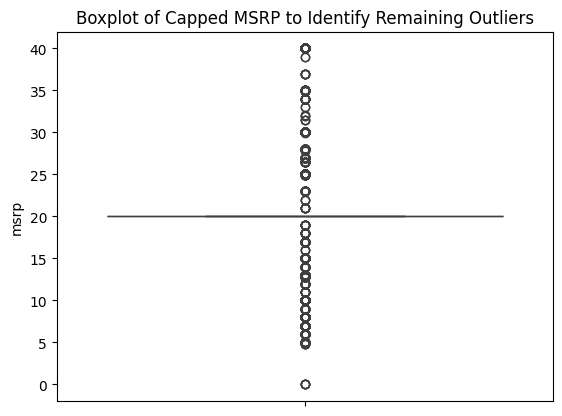

In [60]:
# Identify outliers in the target variable
sns.boxplot(data['msrp'])
plt.title('Boxplot of Capped MSRP to Identify Remaining Outliers')
plt.show()


## Milestone 3 Summary

### Data Cleansing and Preparation
To evaluate models effectively, I established a clean baseline for the data. Since much of the cleansing work was done in prior milestones, there was minimal preparation needed this week. Initially, I ran the models without further transformations, which resulted in poor performance. This prompted me to improve the dataset using more advanced data cleansing and feature engineering.

This week, I primarily dealt with outliers by capping MSRP values at the 90th percentile, focusing on a normal distribution of action figure costs between $5 and $40. Additionally, I leveraged pipeline transformers to apply column transformations to categorical and numerical features, though most of this work was already done in Milestone 2. Overall, this further improved my understanding of pipeline processing, but the gains were modest given the previous effort.

### Model Evaluation

In this milestone, I focused on building and evaluating different models to predict the MSRP of action figures using the data collected in earlier milestones. I evaluated the following models:

* `Linear Regression`: Served as a baseline model. Linear regression is simple, interpretable, and provides a benchmark for evaluating more sophisticated models.
* `Gradient Boosting`: Useful for its capability of sequential learning and minimizing loss functions. It was particularly suitable for a dataset of this size.
* `CatBoost`: Selected for its advanced handling of categorical data and ability to model complex relationships, even though the categorical features were already encoded.
* `LightGBM`: Known for reducing computational time while maintaining accuracy, LightGBM was evaluated as an alternative to other boosting models.
* `XGBoost`: Widely used in data science competitions, XGBoost was included due to its well-balanced performance between bias and variance and improved regularization techniques.

Hyperparameter tuning for all models used GridSearchCV to optimize performance by finding parameter combinations that minimized MAE. This process was experimental, as small parameter tweaks led to significant changes in outcomes.

Additionally, I explored ensemble models:

* `Voting Regressor`: Combined the strengths of each of the boosting models (Gradient, CatBoost, LightGBM, XGBoost) to reduce overall error.
* `Stacking Regressor`: Allowed training a meta-model based on predictions of the base models, enhancing the ability to capture more intricate relationships between predictors.

Combining multiple models yielded more stable predictions by leveraging the strengths of each model type.

### Evaluation Metrics

The following metrics were used to evaluate model performance:

* `Mean Absolute Error (MAE)`: Provided an absolute measure of error that is easy to interpret.
* `Root Mean Squared Error (RMSE)`: Penalizes larger errors more heavily, offering insight into the variance of prediction errors.
* `R-squared and Adjusted R-squared`: Measured how well the features explained the target variable. Adjusted R-squared adjusts for the number of predictors to prevent misleadingly high values due to overfitting.
* `Median Absolute Error (MEDAE)` and `Mean Absolute Percentage Error (MAPE)`: Provided additional context, with `MEDAE` evaluating robustness against outliers and `MAPE` giving a percentage error perspective for interpretability.

### Model Insights and Conclusions

Comparing model performance, the `Stacking Regressor` performed best on metrics like R-squared and MAE. Interestingly, `CatBoost` performed very well with minimal hyperparameter tuning, suggesting that its unique handling of categorical data offered an advantage in this scenario. Given the number of models and their boosting nature, cross-validation was critical to reduce the risk of overfitting.

### Recommendations and Next Steps

The current models did not perform as effectively as hoped, largely because the data lacks strong predictors for MSRP. Certain features that might have influenced MSRP—such as market trends at release, production volume, and availability in mint condition—were missing. Collecting additional data, such as information on film or series releases or rarity indicators, could significantly improve model performance.

I initially aimed to predict future prices by including historical pricing data, but collecting and matching this data from public sources proved difficult. Constraints such as the cost of using APIs like Amazon or eBay also limited data acquisition efforts.

While I considered other modeling approaches like CNNs to classify action figures by image, this proved too complex for the current project timeline and risked derailing the core focus of predicting MSRP.



# Milestone 4 - Final Submission

To wrap up this project, we are required to submit a paper detailing the project.  This can be found in the PDF section of the repository: [here](../supporting-docs/Galactic-Figures-White-Paper.pdf)